<h3>성인 남녀 얼굴 이미지 분류하기 - 이진분류<br>
데이터는 구글 드라이브에 있음.<br>
파일 명에 label로 사용할 힌트가 있다.</h3>

In [1]:
import os, cv2, numpy as np
# cv2 : openCV
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# 이미지 경로
image_dir = '/content/drive/MyDrive/person_img/'
x, y = [], []

# 레이블 구하기 : 30_0_0_20170119195539771.jpg
# gender = int(파일명.split('_')[1]) _를 기준으로 split하고 첫번째 값이 0 : male, 1: female
for file in os.listdir(image_dir):
  try:
    gender = int(file.split('_')[1])
    # 파일 경로 저장
    img_path = os.path.join(image_dir, file)
    # openCV로 이미지 읽기
    img = cv2.imread(img_path)
    # 이미지 크기 조정
    img = cv2.resize(img, (64, 64))
    x.append(img)
    y.append(gender)
  except:
    continue

print(x[0])
print(y[0]) # 1

[[[150 119 108]
  [158 146 138]
  [168 174 174]
  ...
  [144 153 157]
  [150 149 152]
  [146 138 133]]

 [[142 102  84]
  [140 121 108]
  [154 151 145]
  ...
  [138 147 151]
  [144 144 146]
  [138 131 126]]

 [[140  96  75]
  [141 107  93]
  [156 137 129]
  ...
  [138 146 154]
  [143 142 145]
  [138 131 124]]

 ...

 [[ 87  65  61]
  [ 84  70  72]
  [ 77  72  83]
  ...
  [132 169 146]
  [151 200 164]
  [148 203 158]]

 [[ 71  67  85]
  [ 75  72  93]
  [ 77  76 101]
  ...
  [109 132 150]
  [107 147 138]
  [156 205 181]]

 [[ 82  82 106]
  [ 90  87 112]
  [ 94  90 115]
  ...
  [152 167 199]
  [ 94 109 127]
  [ 84 109 109]]]
1


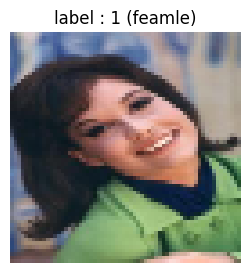

In [2]:
# 첫번째 이미지 시각화
import matplotlib.pyplot as plt

# matplotlib는 RGB로 되어있는데 openCV는 BGR로 되어 있어.
# openCV는 BGR 읽어오기 때문에 matplotlib로(RGB) 읽어오려면 BGR to RGB를 해야함.
img_rgb = cv2.cvtColor(x[0], cv2.COLOR_BGR2RGB)

plt.figure(figsize=(3, 3))

plt.imshow(img_rgb)
plt.title(f'label : {y[0]} ({'male' if y[0]==0 else 'feamle'})')
plt.axis('off')
plt.show()

In [3]:
# 정규화 하기
x = np.array(x) / 255.0
y = np.array(y)

# train / test spilt
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(x_train.shape, x_test.shape) # (102, 64, 64, 3) (26, 64, 64, 3)

(102, 64, 64, 3) (26, 64, 64, 3)


In [4]:
# 모델 생성
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input

model = Sequential([
    Input(shape=(64, 64, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,625,281 (6.20 MB)

 Trainable params: 1,625,281 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

None


In [5]:
# compile / fit
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=2)
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f'test acc : {acc:.4f}')

Epoch 1/20
3/3 - 12s - 4s/step - accuracy: 0.6296 - loss: 0.7595 - val_accuracy: 0.6667 - val_loss: 0.6504
Epoch 2/20
3/3 - 0s - 47ms/step - accuracy: 0.7284 - loss: 0.6108 - val_accuracy: 0.6667 - val_loss: 0.6398
Epoch 3/20
3/3 - 0s - 33ms/step - accuracy: 0.7284 - loss: 0.5417 - val_accuracy: 0.6667 - val_loss: 0.7121
Epoch 4/20
3/3 - 0s - 69ms/step - accuracy: 0.7407 - loss: 0.4954 - val_accuracy: 0.5714 - val_loss: 0.6533
Epoch 5/20
3/3 - 0s - 91ms/step - accuracy: 0.8889 - loss: 0.4757 - val_accuracy: 0.6190 - val_loss: 0.7096
Epoch 6/20
3/3 - 0s - 36ms/step - accuracy: 0.7778 - loss: 0.4212 - val_accuracy: 0.6667 - val_loss: 0.7941
Epoch 7/20
3/3 - 0s - 34ms/step - accuracy: 0.8395 - loss: 0.3841 - val_accuracy: 0.6190 - val_loss: 0.6627
Epoch 8/20
3/3 - 0s - 38ms/step - accuracy: 0.9259 - loss: 0.3300 - val_accuracy: 0.6190 - val_loss: 0.7263
Epoch 9/20
3/3 - 0s - 41ms/step - accuracy: 0.9383 - loss: 0.2685 - val_accuracy: 0.6190 - val_loss: 0.7359
Epoch 10/20
3/3 - 0s - 35ms/s

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
예측값 : [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
실제값 : [0 0 1 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1]


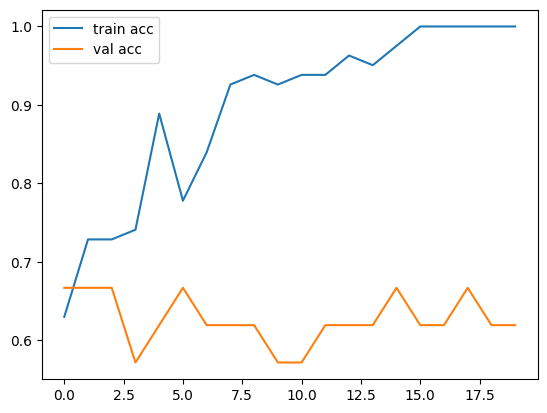

In [7]:
# 예측하기
pred = model.predict(x_test)
print(f'예측값 : {(pred >=5).astype(int).reshape(-1)}')
print(f'실제값 : {y_test}')

# acc에 대한 시각화
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


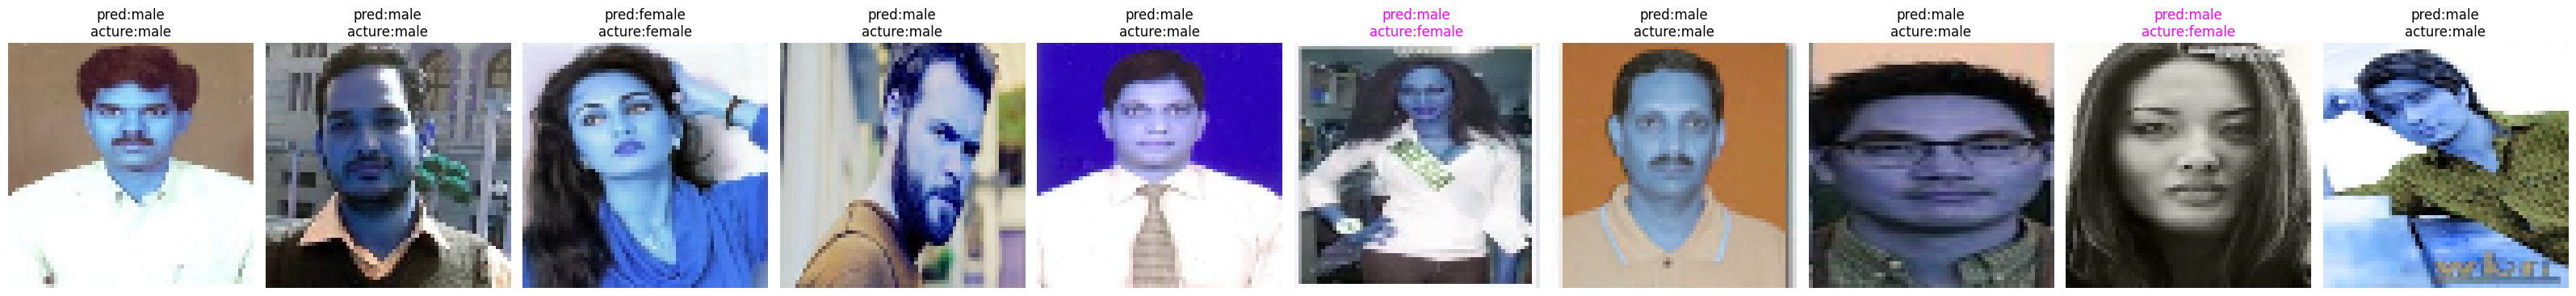

In [11]:
# 5개의 이미지로 분류 예측 시각화
pred = model.predict(x_test[:10])
pred_classes = (pred >= 0.5).astype(int).reshape(-1)
true_classes = y_test[:10]

plt.figure(figsize=(32, 4))
for i in range(10):
  plt.subplot(1, 10, i+1)
  plt.imshow(x_test[i])

  is_correct = pred_classes[i] == true_classes[i]
  label = 'female' if true_classes[i] == 1 else 'male'
  prediction = 'female' if pred_classes[i] == 1 else 'male'
  title_color = 'black' if is_correct else 'magenta'
  plt.title(f'pred:{prediction}\nacture:{label}', color=title_color)
  plt.axis('off')
plt.tight_layout()
plt.show()

# 현재 모델은 학습데이터 부족으로 좋은 결과를 기대하기 어렵다.